In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import urllib
import earthpy as et
import earthpy.spatial as es
import string
from pathlib import Path
import rioxarray as riox
import rasterio as rio
import xrspatial as xrs
import scipy.ndimage as snd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import ScalarFormatter
from shapely.geometry import Polygon, Point, LineString
from shapely.ops import unary_union
from matplotlib_scalebar.scalebar import ScaleBar
from rasterio.mask import mask
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

from datetime import datetime
from datetime import timezone

plt.style.use('default')
#plt.switch_backend('tkagg')
plt.ioff()


In [2]:
import cartopy.geodesic as cgeo

mpl.rcParams['axes.linewidth'] = 0.1

def _axes_to_lonlat(ax, coords):
    """(lon, lat) from axes coordinates."""
    display = ax.transAxes.transform(coords)
    data = ax.transData.inverted().transform(display)
    lonlat = ccrs.PlateCarree().transform_point(*data, ax.projection)

    return lonlat


def _upper_bound(start, direction, distance, dist_func):
    """A point farther than distance from start, in the given direction.

    It doesn't matter which coordinate system start is given in, as long
    as dist_func takes points in that coordinate system.

    Args:
        start:     Starting point for the line.
        direction  Nonzero (2, 1)-shaped array, a direction vector.
        distance:  Positive distance to go past.
        dist_func: A two-argument function which returns distance.

    Returns:
        Coordinates of a point (a (2, 1)-shaped NumPy array).
    """
    if distance <= 0:
        raise ValueError(f"Minimum distance is not positive: {distance}")

    if np.linalg.norm(direction) == 0:
        raise ValueError("Direction vector must not be zero.")

    # Exponential search until the distance between start and end is
    # greater than the given limit.
    length = 0.1
    end = start + length * direction

    while dist_func(start, end) < distance:
        length *= 2
        end = start + length * direction

    return end


def _distance_along_line(start, end, distance, dist_func, tol):
    """Point at a distance from start on the segment  from start to end.

    It doesn't matter which coordinate system start is given in, as long
    as dist_func takes points in that coordinate system.

    Args:
        start:     Starting point for the line.
        end:       Outer bound on point's location.
        distance:  Positive distance to travel.
        dist_func: Two-argument function which returns distance.
        tol:       Relative error in distance to allow.

    Returns:
        Coordinates of a point (a (2, 1)-shaped NumPy array).
    """
    initial_distance = dist_func(start, end)
    if initial_distance < distance:
        raise ValueError(f"End is closer to start ({initial_distance}) than "
                         f"given distance ({distance}).")

    if tol <= 0:
        raise ValueError(f"Tolerance is not positive: {tol}")

    # Binary search for a point at the given distance.
    left = start
    right = end

    while not np.isclose(dist_func(start, right), distance, rtol=tol):
        midpoint = (left + right) / 2

        # If midpoint is too close, search in second half.
        if dist_func(start, midpoint) < distance:
            left = midpoint
        # Otherwise the midpoint is too far, so search in first half.
        else:
            right = midpoint

    return right


def _point_along_line(ax, start, distance, angle=0, tol=0.01):
    """Point at a given distance from start at a given angle.

    Args:
        ax:       CartoPy axes.
        start:    Starting point for the line in axes coordinates.
        distance: Positive physical distance to travel.
        angle:    Anti-clockwise angle for the bar, in radians. Default: 0
        tol:      Relative error in distance to allow. Default: 0.01

    Returns:
        Coordinates of a point (a (2, 1)-shaped NumPy array).
    """
    # Direction vector of the line in axes coordinates.
    direction = np.array([np.cos(angle), np.sin(angle)])

    geodesic = cgeo.Geodesic()

    # Physical distance between points.
    def dist_func(a_axes, b_axes):
        a_phys = _axes_to_lonlat(ax, a_axes)
        b_phys = _axes_to_lonlat(ax, b_axes)

        # Geodesic().inverse returns a NumPy MemoryView like [[distance,
        # start azimuth, end azimuth]].
        return geodesic.inverse(a_phys, b_phys).base[0, 0]

    end = _upper_bound(start, direction, distance, dist_func)

    return _distance_along_line(start, end, distance, dist_func, tol)


def scale_bar(ax, location, length, metres_per_unit=1000, unit_name='km',
              tol=0.01, angle=0, color='black', linewidth=3, text_offset=0.005,
              ha='center', va='bottom', plot_kwargs=None, text_kwargs=None,
              **kwargs):
    """Add a scale bar to CartoPy axes.

    For angles between 0 and 90 the text and line may be plotted at
    slightly different angles for unknown reasons. To work around this,
    override the 'rotation' keyword argument with text_kwargs.

    Args:
        ax:              CartoPy axes.
        location:        Position of left-side of bar in axes coordinates.
        length:          Geodesic length of the scale bar.
        metres_per_unit: Number of metres in the given unit. Default: 1000
        unit_name:       Name of the given unit. Default: 'km'
        tol:             Allowed relative error in length of bar. Default: 0.01
        angle:           Anti-clockwise rotation of the bar.
        color:           Color of the bar and text. Default: 'black'
        linewidth:       Same argument as for plot.
        text_offset:     Perpendicular offset for text in axes coordinates.
                         Default: 0.005
        ha:              Horizontal alignment. Default: 'center'
        va:              Vertical alignment. Default: 'bottom'
        **plot_kwargs:   Keyword arguments for plot, overridden by **kwargs.
        **text_kwargs:   Keyword arguments for text, overridden by **kwargs.
        **kwargs:        Keyword arguments for both plot and text.
    """
    # Setup kwargs, update plot_kwargs and text_kwargs.
    if plot_kwargs is None:
        plot_kwargs = {}
    if text_kwargs is None:
        text_kwargs = {}

    plot_kwargs = {'linewidth': linewidth, 'color': color, **plot_kwargs,
                   **kwargs}
    text_kwargs = {'ha': ha, 'va': va, 'rotation': angle, 'color': color,
                   **text_kwargs, **kwargs}

    # Convert all units and types.
    location = np.asarray(location)  # For vector addition.
    length_metres = length * metres_per_unit
    angle_rad = angle * np.pi / 180

    # End-point of bar.
    end = _point_along_line(ax, location, length_metres, angle=angle_rad,
                            tol=tol)

    # Coordinates are currently in axes coordinates, so use transAxes to
    # put into data coordinates. *zip(a, b) produces a list of x-coords,
    # then a list of y-coords.
    ax.plot(*zip(location, end), transform=ax.transAxes, **plot_kwargs)

    # Push text away from bar in the perpendicular direction.
    midpoint = (location + end) / 2
    offset = text_offset * np.array([-np.sin(angle_rad), np.cos(angle_rad)])
    text_location = midpoint + offset

    # 'rotation' keyword argument is in text_kwargs.
    ax.text(*text_location, f"{length} {unit_name}", rotation_mode='anchor',
            transform=ax.transAxes, **text_kwargs)


#%%

def add_north_arrow(ax, xy=(0.95, 0.95), size=0.1, color='black', text_color='black'):
    arrow_style = dict(facecolor=color, edgecolor=color, arrowstyle='->', linewidth=1.5)
    ax.annotate('', xytext=(xy[0], xy[1] - size), xy=(xy[0], xy[1] + size), arrowprops=arrow_style)
    ax.text(xy[0], xy[1], 'N', transform=ax.transAxes, color=text_color, ha='center', va='center', fontsize=10)


In [3]:
# include alaska inset and scale bar/north arrow
#%% https://stackoverflow.com/questions/32333870/how-can-i-show-a-km-ruler-on-a-cartopy-matplotlib-plot/50674451#50674451


#%%

lonW = -136
lonE = -133.5
latS = 58.25
latN = 60.25

extent = [lonW, lonE, latS, latN]
extent_polygon = Polygon([(lonW, latS), (lonW, latN), (lonE, latN), (lonE, latS)])

# lonW = -134.5
# lonE = -133.5
# latS = 58
# latN = 59.5

# import elevation
# # clip the SRTM1 30m DEM of Rome and save it to Rome-DEM.tif
# elevation.clip(bounds=(latS, lonW, latN, lonE), output='jif.tif')
# clean up stale temporary files and fix the cache in the event of a server error
#elevation.clean()


p = Path("/Users/drotto/src/jiflr/data/external/arcticDEM_32.tif")
print(p)
dem = riox.open_rasterio(p, chunks={"x":1000, "y":1000}, mask_and_scale=True).sel(band=1)
#dem_ccrs = ccrs.epsg(dem.rio.crs.to_epsg())
dem = dem.rio.reproject(ccrs.PlateCarree())
dem = dem.rio.clip_box(
    minx=lonW,
    miny=latS,
    maxx=lonE,
    maxy=latN,
    crs=ccrs.PlateCarree(),
)
dem.values = np.where(dem.values < 0, np.nan, dem.values)


#%%

def nn_fill(arr):
    mask = np.isnan(arr)
    idx = np.where(~mask, np.arange(mask.shape[1]), 0)
    np.maximum.accumulate(idx, axis=1, out=idx)
    arr[mask] = arr[np.nonzero(mask)[0], idx[mask]]
    return arr

dem.values = nn_fill(dem.values)


#%%


# load rgi7
# todo: make into fn in data file
p = Path("/Users/drotto/src/jiflr/data/external/rgi7/RGI2000-v7.0-G-01_alaska")
rgi = gpd.read_file(p)

p = Path("/Users/drotto/src/jiflr/data/external/rgi7/RGI2000-v7.0-C-01_alaska")
rgic = gpd.read_file(p)
rgic = rgic.sort_values(by='area_km2', ascending=False)

jif = rgic.iloc[[5]].to_crs(ccrs.PlateCarree())

rgi = rgi.cx[lonW:lonE, latS:latN]
rgi = rgi.to_crs(crs=ccrs.PlateCarree())

rgi_jif = rgi.clip(jif)
rgi_other = rgi.loc[[idx for idx in rgi.index if idx not in rgi_jif.index]]

# Clip the DEM using the polygon
jif_dem = dem.rio.clip(jif.geometry)
dem_icefree = dem.rio.clip(rgi.geometry, invert=True)

#%%

ocean = gpd.GeoSeries(cfeature.GSHHSFeature(scale='full', levels=[1]).intersecting_geometries(extent))
lakes = gpd.GeoSeries(cfeature.GSHHSFeature(scale='full', levels=[2]).intersecting_geometries(extent))
islands =gpd.GeoSeries(cfeature.GSHHSFeature(scale='full', levels=[3]).intersecting_geometries(extent))

ocean = gpd.GeoSeries(extent_polygon).symmetric_difference(ocean.unary_union)
lakes = lakes.difference(islands.unary_union)



/Users/drotto/src/jiflr/data/external/arcticDEM_32.tif


/Users/drotto/micromamba/envs/jiflr/lib/python3.11/site-packages/shapely/set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


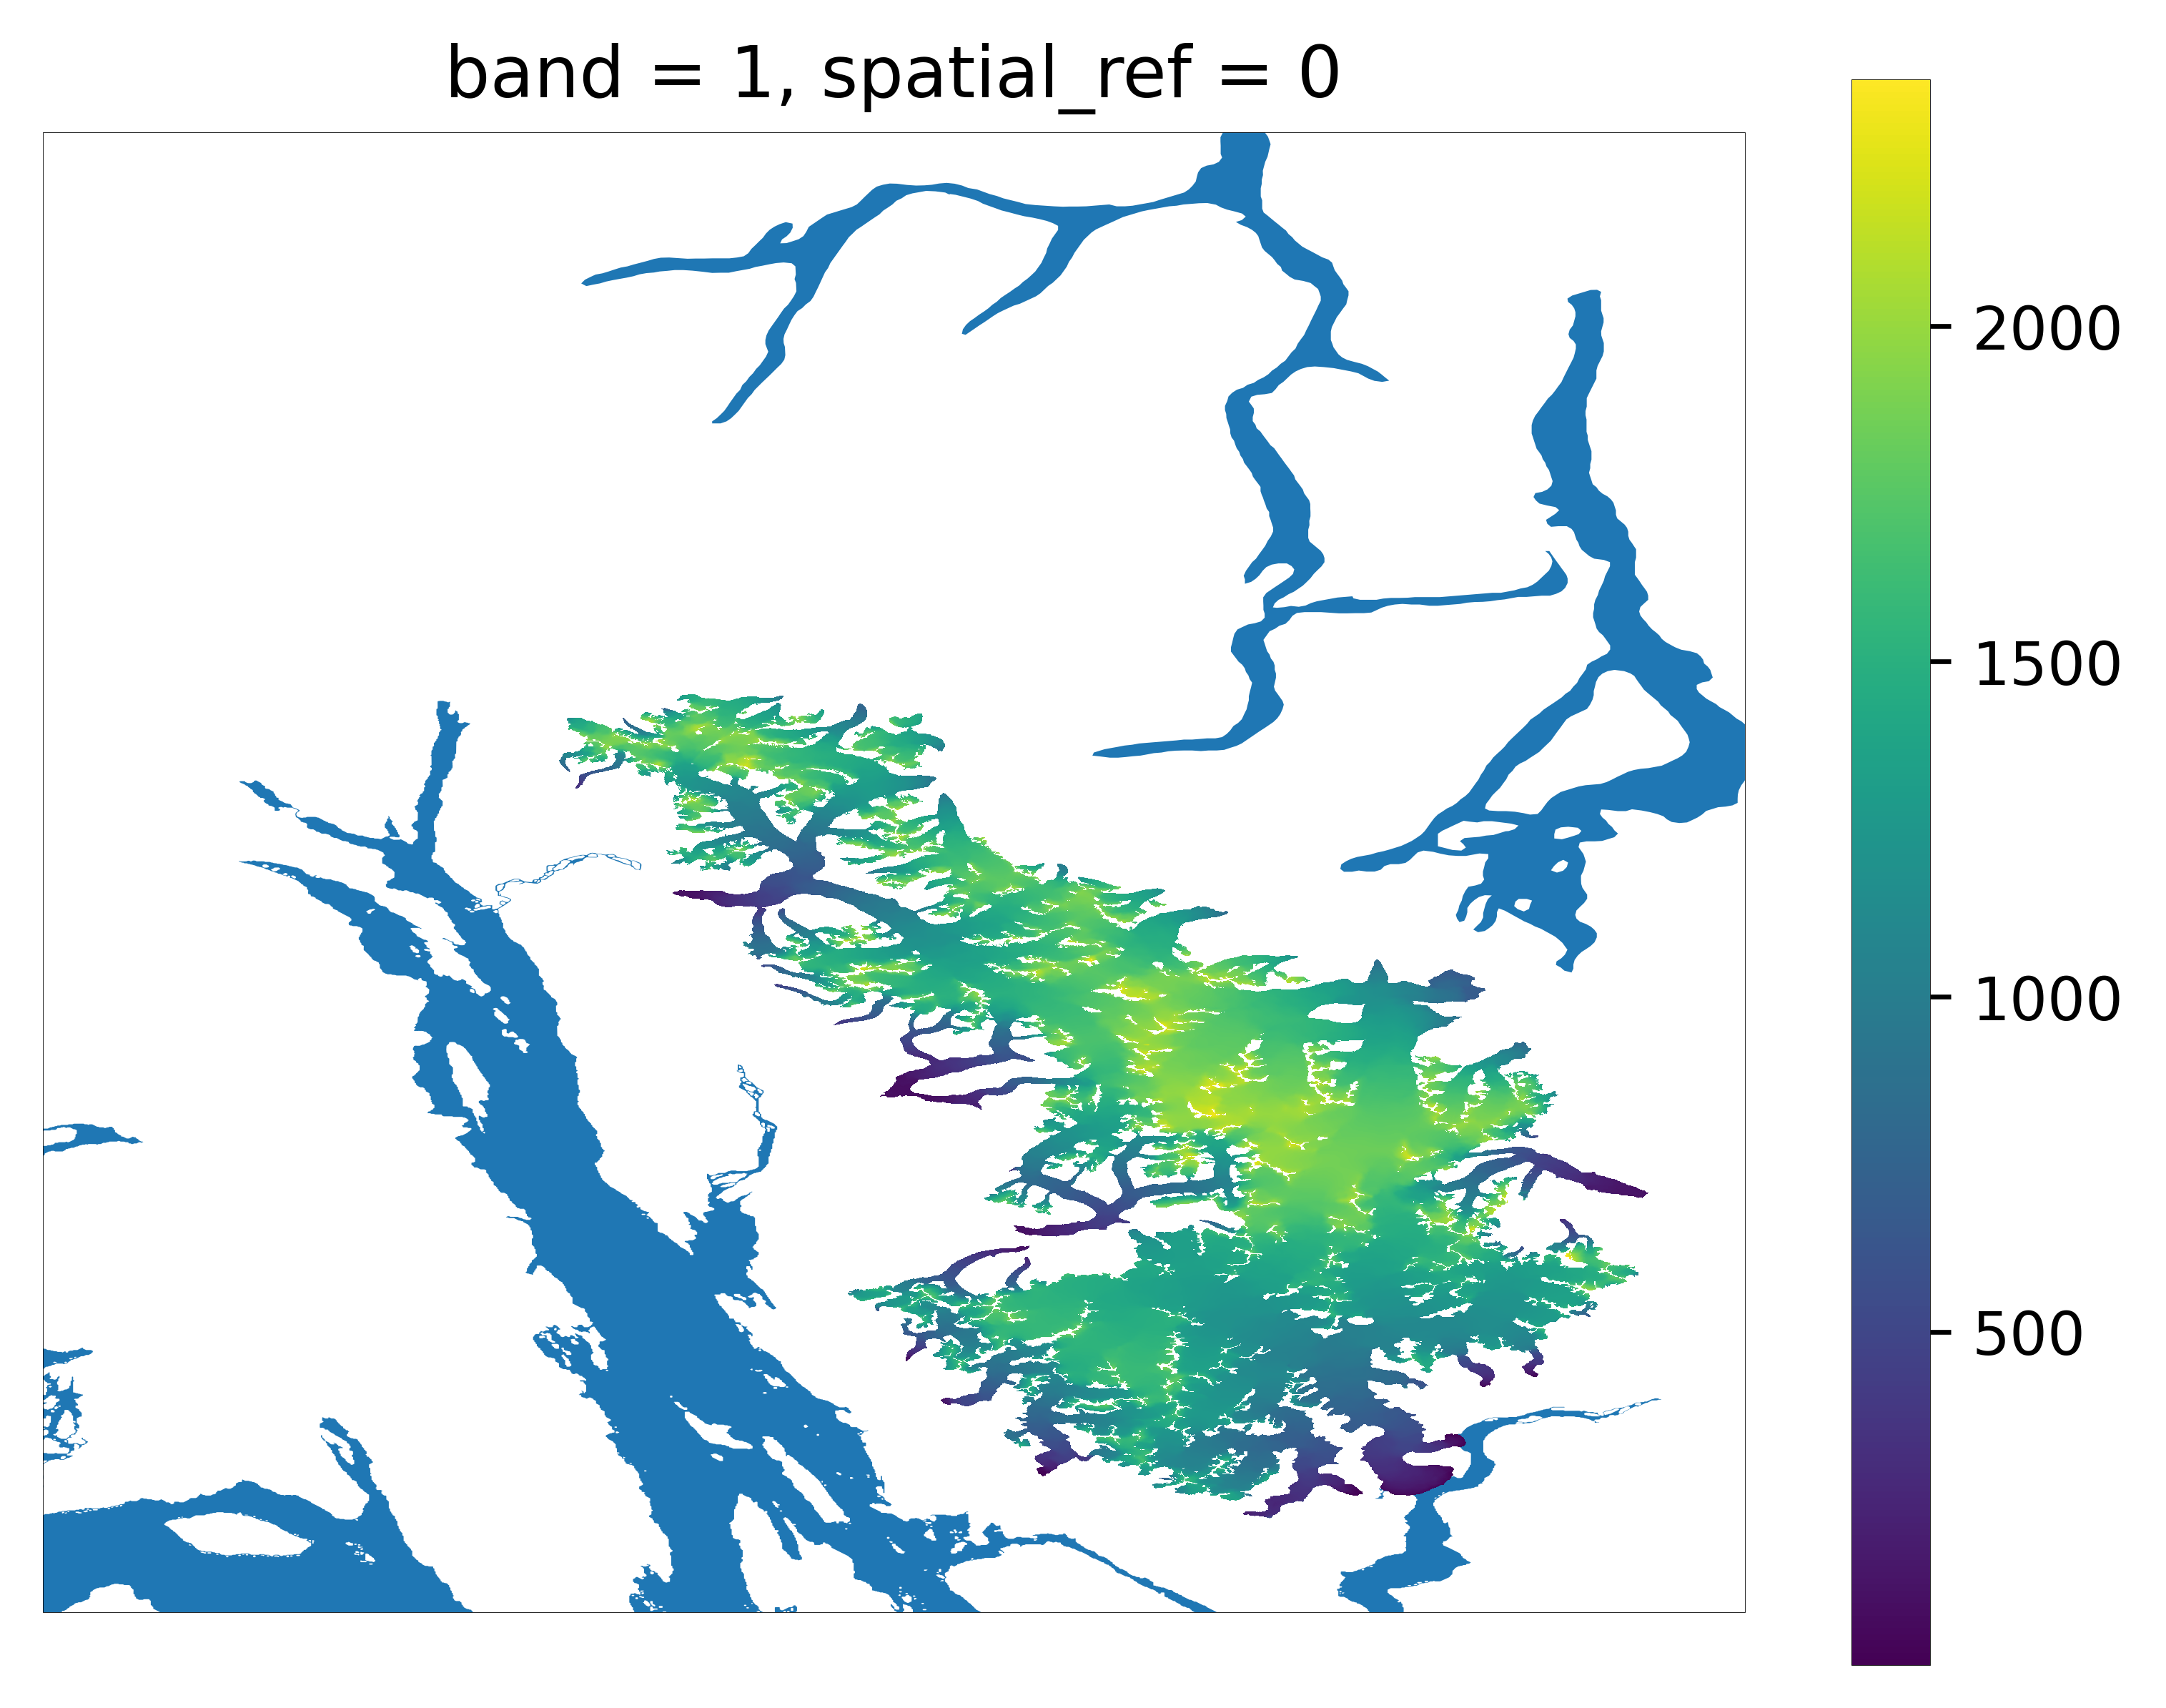

In [5]:
fig, mapax = plt.subplots(1,1, subplot_kw={'projection': ccrs.PlateCarree()}, dpi=600)
mapax.set_extent([lonW+0.1, lonE-0.1, latS, latN], crs=ccrs.PlateCarree())
ocean.plot(ax=mapax)
lakes.plot(ax=mapax)
jif_dem.plot(ax=mapax)
jif_cmap = mpl.colors.LinearSegmentedColormap.from_list("jif_cmap", plt.cm.BuPu(np.linspace(0.5, 0, 256)))

scalebar = AnchoredSizeBar(mapax.transData,
                           200, '20 km', 'lower left',
                           pad=0.1,
                           color='black',
                           frameon=True,
                           zorder=10,
                           size_vertical=1)

plt.savefig(f'test_{datetime.now().strftime("%Y%m%d-%H%M%S")}.png')

In [4]:
#%% Load geoJSON
# Load and process the GeoJSON data
import json

# Function to create a GeoDataFrame from GeoJSON features
def create_gdf_from_features(features, feature_class=None, folder_id=None):
    # Filter features by class and/or folder ID if specified
    if feature_class:
        features = [f for f in features if f['properties'].get('class') == feature_class]
    if folder_id:
        features = [f for f in features if f['properties'].get('folderId') == folder_id]
    
    if not features:
        return None
    
    # Extract geometries and properties
    geometries = []
    properties = []
    
    for feature in features:
        if feature['geometry'] is not None:
            geom_type = feature['geometry']['type']
            coords = feature['geometry']['coordinates']
            
            if geom_type == 'Point':
                geometry = Point(coords[0], coords[1])
            elif geom_type == 'LineString':
                geometry = LineString(coords)
            elif geom_type == 'Polygon':
                geometry = Polygon(coords[0])
            else:
                continue
                
            geometries.append(geometry)
            properties.append(feature['properties'])
    
    if not geometries:
        return None
        
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(properties, geometry=geometries, crs='EPSG:4326')
    return gdf

# Load the GeoJSON data
with open("/Users/drotto/Downloads/JIF_Lapse_Rate_2025_-_for-show.json", 'r') as f:
    geojson_data = json.load(f)

# Extract folders
folders = [f for f in geojson_data['features'] if f['properties'].get('class') == 'Folder']
folder_map = {f['id']: f['properties']['title'] for f in folders}

# Extract all markers and shapes
markers_gdf = create_gdf_from_features(geojson_data['features'], 'Marker')
shapes_gdf = create_gdf_from_features(geojson_data['features'], 'Shape')

# Group markers by color for visualization
marker_categories = {}
if markers_gdf is not None:
    for idx, row in markers_gdf.iterrows():
        color = row.get('marker-color', '#000000')
        if color not in marker_categories:
            marker_categories[color] = gpd.GeoDataFrame(columns=markers_gdf.columns)
        marker_categories[color] = pd.concat([marker_categories[color], gpd.GeoDataFrame([row])])

# Create specific category GeoDataFrames for special folders
camps_markers = create_gdf_from_features(
    geojson_data['features'], 
    'Marker', 
    next((f['id'] for f in folders if f['properties']['title'] == 'A - Camps'), None)
)

stakes_markers = create_gdf_from_features(
    geojson_data['features'], 
    'Marker', 
    next((f['id'] for f in folders if f['properties']['title'] == 'Stake Locations 2024'), None)
)

pits_markers = create_gdf_from_features(
    geojson_data['features'], 
    'Marker', 
    next((f['id'] for f in folders if f['properties']['title'] == 'MB Pits'), None)
)


#%%
# Define the coordinates for Juneau and Skagway
coords = {
    "Juneau": Point(-134.41922712082635, 58.30043883194991),
    "Skagway": Point(-135.3287066398975, 59.459528564092096),
    "Atlin": Point(-133.70391, 59.57400),
    "Carcross": Point(-134.70940256243654, 60.16984901240911),
}
coords = gpd.GeoDataFrame(geometry=list(coords.values()), index=coords.keys(), crs='EPSG:4326')

main_transect = LineString([
    (59.459528564092096, -135.3287066398975),
    (60.16984901240911, -134.70940256243654)
])
distances = np.linspace(0, main_transect.length, 30)
points = [main_transect.interpolate(distance) for distance in distances]
transect_pts = LineString(points)

control_transect = LineString([
    (58.30043883194991, -134.41922712082635),
    (59.57400, -133.70391,)
])
distances = np.linspace(0, control_transect.length, 30)
points = [control_transect.interpolate(distance) for distance in distances]
control_pts = LineString(points)



prelim_pts = {
    "Taku A": Point( -134.16295, 58.63179,),
    "Taku B": Point(-134.19604, 58.65725),
    "Heather Camp": Point(-134.29072, 58.83294),
    #"Mt. Moore": Point(-134.14002, 58.80600)
} 
prelim_pts = gpd.GeoDataFrame(geometry=list(prelim_pts.values()), index=prelim_pts.keys(), crs='EPSG:4326')

# wx locations
wx_pts = pd.read_csv(Path("/Users/drotto/src/jiflr/_to_merge/jirp23_lapse_rate/Data/JIRP_AWS_Stations/juneauIceField_weather_v1.0/WeatherStationLocations.csv"))
# Convert the pandas DataFrame to a GeoDataFrame
wx_pts = gpd.GeoDataFrame(
    wx_pts, 
    geometry=gpd.points_from_xy(wx_pts['Longitude'], wx_pts['Latitude']),
    crs='EPSG:4326'  # Assuming the coordinates are in WGS84
)
wx_pts = {
    'Camp 17': Point(58.36737, -134.36638),
    'Camp 10': Point(58.71243, -134.18222),
    'Camp 9': Point(58.64721, -134.20635),
    'Camp 18': Point(58.83497, -134.27643),
    'Camp 8': Point(58.80670, -134.13613),
    'Camp 25': Point(58.95560, -134.32425),
    'Camp 26': Point(59.01664, -134.12104),
    'Camp 29': Point(59.34211, -134.10221),   
}
wx_pts = gpd.GeoDataFrame(geometry=list(wx_pts.values()), index=wx_pts.keys(), crs='EPSG:4326')

#wx_pts.loc[:,'Location'] = wx_pts['Location'].iloc[[2,4,6,7,1,0,3,5]].reset_index(drop=True)
#wx_pts = wx_pts.loc[~(wx_pts.Location == 'C-30')]

# import proposed 2025 pts
p = Path("2025-proposed-points.csv")
stakes_2025 = pd.read_csv(p)


/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_78297/687288038.py:63: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  marker_categories[color] = pd.concat([marker_categories[color], gpd.GeoDataFrame([row])])
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_78297/687288038.py:63: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  marker_categories[color] = pd.concat([marker_categories[color], gpd.GeoDataFrame([row])])


In [5]:
print(stakes_2025)

                         Label                                 Icon  \
0   WS - Summit Cr near Fraser  /icon@2x.png?cfg=point%2CFF0000%231   
1            WS - Skagway 6 NE  /icon@2x.png?cfg=point%2CFF0000%231   
2                 WS - Skagway  /icon@2x.png?cfg=point%2CFF0000%231   
3             WS - Moore Cr Br  /icon@2x.png?cfg=point%2CFF0000%231   
4            WS - Klondike Hwy  /icon@2x.png?cfg=point%2CFF0000%231   
5          WS - Haines Airport  /icon@2x.png?cfg=point%2CFF0000%231   
6               WS - Fraser 1S  /icon@2x.png?cfg=point%2CFF0000%231   
7                    Stake F16  /icon@2x.png?cfg=point%2CFF0000%231   
8                    Stake F15  /icon@2x.png?cfg=point%2CFF0000%231   
9                    Stake D14  /icon@2x.png?cfg=point%2CFF0000%231   
10                   Stake C13  /icon@2x.png?cfg=point%2CFF0000%231   
11                   Stake C12  /icon@2x.png?cfg=point%2CFF0000%231   
12                   Stake C11  /icon@2x.png?cfg=point%2CFF0000%231   
13    

In [6]:
# Process the Position column to extract latitude and longitude
def extract_coords(position_str):
    # Split the string and convert to float
    lat_str, lon_str = position_str.split(', ')
    return float(lat_str), float(lon_str)

# Create new latitude and longitude columns
stakes_2025[['latitude', 'longitude']] = stakes_2025['Position'].apply(lambda x: pd.Series(extract_coords(x)))

# Create geometry column with Shapely Point objects
geometry = [Point(lon, lat) for lat, lon in zip(stakes_2025['latitude'], stakes_2025['longitude'])]

# Create GeoDataFrame
stakes_2025 = gpd.GeoDataFrame(stakes_2025, geometry=geometry, crs="EPSG:4326")

# Clean up the GeoDataFrame
# Drop the original Position column if not needed
stakes_2025 = stakes_2025.drop('Position', axis=1)

# Print the first few rows of the GeoDataFrame
stakes_2025

,Label,Icon,Updated,Visible,latitude,longitude,geometry
0,WS - Summit Cr near Fraser,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,59.65361,-135.14361,POINT (-135.14361 59.65361)
1,WS - Skagway 6 NE,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,59.52722,-135.23194,POINT (-135.23194 59.52722)
2,WS - Skagway,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,59.45440,-135.32630,POINT (-135.32630 59.45440)
3,WS - Moore Cr Br,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,59.58783,-135.21050,POINT (-135.21050 59.58783)
4,WS - Klondike Hwy,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,59.62964,-135.16420,POINT (-135.16420 59.62964)
5,WS - Haines Airport,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,59.24287,-135.51139,POINT (-135.51139 59.24287)
6,WS - Fraser 1S,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,59.71533,-135.05085,POINT (-135.05085 59.71533)
7,Stake F16,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,58.63800,-134.55505,POINT (-134.55505 58.63800)
8,Stake F15,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,58.67480,-134.52312,POINT (-134.52312 58.67480)
9,Stake D14,/icon@2x.png?cfg=point%2CFF0000%231,"Wed, 19 Mar 2025 13:41:14 GMT",visible,58.68230,-134.38957,POINT (-134.38957 58.68230)


In [9]:
# Convert integer list to strings
camps_to_keep = [str(camp) for camp in [17, 10, 9, 18, 25, 8, 26]]

# Then filter
filtered_camps_markers = camps_markers.loc[camps_markers['title'].isin(camps_to_keep), :]
filtered_camps_markers


,creator,description,title,stroke,marker-size,folderId,marker-rotation,marker-symbol,marker-color,stroke-width,class,updated,timestamp,geometry
0,0HPU0T,,25,#FF0000,0.75,e39a125f-6c9a-410e-b3c4-470c06c14caa,None,c:ring,000000,2.0,Marker,1740770791804,1.656133e+12,POINT (-134.32306 58.95099)
1,0HPU0T,,10,NaN,0.75,e39a125f-6c9a-410e-b3c4-470c06c14caa,None,c:ring,000000,NaN,Marker,1740770621259,1.654218e+12,POINT (-134.20673 58.64740)
3,0HPU0T,,17,NaN,0.75,e39a125f-6c9a-410e-b3c4-470c06c14caa,None,c:ring,000000,NaN,Marker,1740770621267,1.659559e+12,POINT (-134.36604 58.36748)
4,0HPU0T,,18,NaN,0.75,e39a125f-6c9a-410e-b3c4-470c06c14caa,None,c:ring,000000,NaN,Marker,1740770621270,1.654225e+12,POINT (-134.27605 58.83484)
8,0HPU0T,,26,NaN,0.75,e39a125f-6c9a-410e-b3c4-470c06c14caa,None,c:ring,000000,NaN,Marker,1740770621282,NaN,POINT (-134.12075 59.01723)
12,0HPU0T,,8,NaN,0.75,e39a125f-6c9a-410e-b3c4-470c06c14caa,None,c:ring,000000,NaN,Marker,1740770621295,1.654225e+12,POINT (-134.13518 58.80674)
25,0HPU0T,,9,NaN,0.75,e39a125f-6c9a-410e-b3c4-470c06c14caa,None,c:ring,000000,NaN,Marker,1740770621361,1.658512e+12,POINT (-134.18180 58.71277)


In [10]:
import matplotlib.path as mpath

vmin=0
vmax=2500
colors = [(0, "#C7DDE7"),  # deeper water          
          (10/vmax, "#5CAE88"),  # dark green
          (750/vmax, "#b1cdb6"),  # light green
          (1250/vmax, "#C4AD9F"),  # brown rock
          (2000/vmax, "#cdc5b0"),  # tan rock
          (1, "#f6f6f8")]  # white
ocean_color = lake_color = "#E8F3F8"
terrain_cmap = mpl.colors.LinearSegmentedColormap.from_list('terrain_map', colors)
cmap = terrain_cmap
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# create hillshade
ls = mpl.colors.LightSource(azdeg=290, altdeg=45)
ls = mpl.colors.LightSource(azdeg=30, altdeg=40)
rgb = cmap(norm(dem.values))
dem_smooth = snd.gaussian_filter(dem.values, sigma=4)
hillshade = ls.shade_rgb(rgb, elevation=dem_smooth, blend_mode='soft',
                      vert_exag=1.0,)


/Users/drotto/micromamba/envs/jiflr/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1642: UserWarning: The following kwargs were not used by contour: 'lw'
  result = super().contourf(*args, **kwargs)
/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_23215/2836818393.py:129: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  road = road.iloc[[0]]['geometry'].explode().iloc[0]


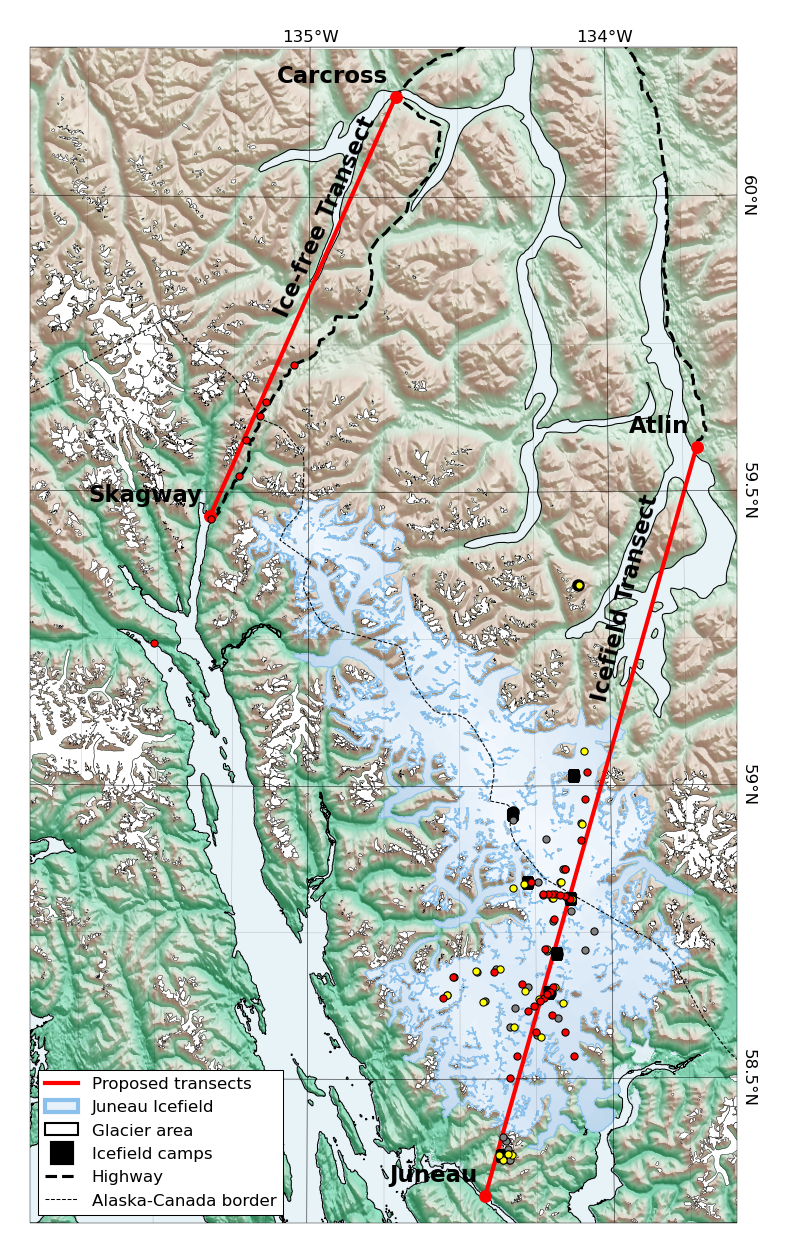

In [88]:

#%%

# todo: tagish lake? douglas island
# todo: clip the dem over water or coverthe contours

#res = '10m' 
# res = '100m'  # for faster plotting
cLat = (latN + latS) / 2
cLon = (lonW + lonE) / 2
proj = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)

aspect_ratio = np.maximum(*dem.shape)/np.minimum(*dem.shape)
width = 3.25

fig = plt.figure(figsize=(width, width*aspect_ratio),dpi=300, layout='constrained', linewidth=0.25)
mapax = fig.add_subplot(111, projection=proj)
extent = [lonW+0.1, lonE-0.1, latS, latN]
mapax.set_extent(extent, crs=ccrs.PlateCarree())

# Clip the boundary to the projection to make it pretty
# # Create 1D arrays for longitude and latitude
# lons = [extent[1], extent[0]]
# lats = [extent[2], extent[3]]

# # Create a 2D grid
# lon_grid, lat_grid = np.meshgrid(lons, lats)

# # Combine into a single array with shape (N, 2) where N = n_lon * n_lat
# bounds = np.column_stack((lon_grid.flatten(), lat_grid.flatten()))
# print(bounds)
# boundary = mpath.Path(bounds)
# mapax.set_boundary(boundary, transform=mapax.transAxes)
#mapax.set_aspect("equal", adjustable='box')

###################################################################################
# Plot hillshade, landscape features
###################################################################################

mapax.imshow(
    hillshade,
    origin='lower',
    extent=[dem.x.min(), dem.x.max(), dem.y.max(), dem.y.min()],
    transform=ccrs.PlateCarree()
)

ocean.plot(ax=mapax, fc=ocean_color, ec='black', lw=0.25, transform=ccrs.PlateCarree())
lakes.plot(ax=mapax, fc=lake_color, ec='black', lw=0.25, transform=ccrs.PlateCarree())



rgi_other.plot(
    ax=mapax,
    legend=False,
    transform=ccrs.PlateCarree(),
    color='#FFF',
    lw=0.1,
    #alpha=0.9,
    #ec='#A7DBF9',
    #ec="#8ACBED",
    ec='#000',
    zorder=1.9,
)

###################################################################################
# Plot JIF outline
###################################################################################

jif.plot(
    #column="rgi_id",
    ax=mapax,
    legend=False,
    #color='#D8F0FB',
    lw=0.25,
    ec="#8AC0EC",
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=1.9,
    marker=''
)

###################################################################################
# Plot JIF DEM, contours
###################################################################################

jif_bounds = tuple(np.array(jif_dem.rio.bounds())[[0, 2, 3, 1]])
dem_bounds = tuple(np.array(dem.rio.bounds())[[0, 2, 3, 1]])
maj_levels = np.arange(vmin, vmax, 250)
jif_cmap = mpl.colors.LinearSegmentedColormap.from_list("jif_cmap", plt.cm.Blues(np.linspace(0.3, 0, 256)))
clevels = np.arange(vmin, vmax-200, 100)
mapax.contourf(
    jif_dem,
    cmap=jif_cmap,
    zorder=1.8,
    extent=jif_bounds,
    levels=clevels,
    transform=ccrs.PlateCarree(),
    lw=0,
)
# cmaj_jif = mapax.contour(
#     jif_dem,
#     levels=maj_levels,
#     colors='#445E74',
#     linewidths=0.1,
#     extent=jif_bounds,
#     transform=ccrs.PlateCarree(),
#     zorder=1.9,
# )
# mapax.clabel(cmaj_jif, cmaj_jif.levels, inline=True, fontsize=1)
# # off-ice contours
# cmaj = mapax.contour(
#     dem_icefree,
#     levels=np.arange(vmin, vmax, 500),
#     colors='black',
#     linewidths=0.1,
#     linestyle=":",
#     extent=dem_bounds,
#     transform=ccrs.PlateCarree(),
#     zorder=1.9,
# )
# mapax.clabel(cmaj, cmaj.levels, inline=True, fontsize=1)


###################################################################################
# Plot build geography
###################################################################################

# Plot the highway and international border
road = gpd.read_file(Path("/Users/drotto/src/jiflr/data/external/skagway-to-atlin.geojson"))
road = road.iloc[[0]]['geometry'].explode().iloc[0]
road = road.segmentize(1)
y,x,_ = zip(*road.coords)
mapax.plot(y, x, lw=0.75, ls="--", color='black', transform=ccrs.PlateCarree())
mapax.add_feature(cfeature.BORDERS.with_scale('10m'), edgecolor='black', lw=0.25, zorder=1.9, ls='--')


# Plot the cities
mapax.scatter(coords.geometry.x, coords.geometry.y, s=8, lw=0.25, color='red', transform=ccrs.PlateCarree(), zorder=2)
# Annotate the points
for x, y, label in zip(coords.geometry.x, coords.geometry.y, coords.index):
    mapax.text(x-0.025, y+0.025, label, fontsize=5.5, ha='right', fontweight='bold', transform=ccrs.PlateCarree())


###################################################################################
# Plot transects
###################################################################################

# plot the main transect
y,x = zip(*main_transect.coords)
mapax.plot(x, y, lw=1, c='red', marker='', transform=ccrs.PlateCarree(), zorder=2)
# plot the 2nd transect
y,x = zip(*control_transect.coords)
mapax.plot(x, y, lw=1, c='red', marker='', transform=ccrs.PlateCarree(), zorder=2)
# annotate transects
mapax.text(-134.07,59.14804,  "Icefield Transect", fontsize=5.5, rotation=76, fontweight="bold", transform=ccrs.PlateCarree())
mapax.text(-135.1289,59.8004,  "Ice-free Transect", fontsize=5.5, rotation=66, fontweight="bold", transform=ccrs.PlateCarree())


###################################################################################
# plot wx locations
###################################################################################

for y, x, label in zip(wx_pts.geometry.x, wx_pts.geometry.y, wx_pts.index):
    mapax.plot(x, y, lw=0, markersize=3, markeredgewidth=0, 
               c='black', marker='o', transform=ccrs.PlateCarree(), zorder=1.9)
    

###################################################################################
# plot contents of the geojason
###################################################################################

# # Plot shapes (lines)
# if shapes_gdf is not None:
#     for idx, shape in shapes_gdf.iterrows():
#         color = 'black'
#         width = 1
#         opacity = 1
        
#         # For LineString features
#         if shape.geometry.geom_type == 'LineString':
#             x, y = shape.geometry.xy
#             mapax.plot(
#                 x, y, 
#                 transform=ccrs.PlateCarree(),
#                 color=color,
#                 linewidth=width,
#                 alpha=opacity,
#                 zorder=2.2
#             )

# Plot camps with special styling (if desired)
if filtered_camps_markers is not None:
    mapax.scatter(
        filtered_camps_markers.geometry.x, filtered_camps_markers.geometry.y,
        transform=ccrs.PlateCarree(),
        color='black',
        s=5,
        marker='s',
        edgecolor='black',
        linewidth=0.5,
        zorder=2.6,
        label='Camps'
    )
# if label in ['Camp 17', 'Camp 10', 'Camp 18']:
#         mapax.text(x+0.01, y+0.02, label, fontsize=4.5, ha='left', fontweight='bold', transform=ccrs.PlateCarree())

# Plot 2024 stakes
if stakes_markers is not None:
    mapax.scatter(
        stakes_markers.geometry.x, stakes_markers.geometry.y,
        transform=ccrs.PlateCarree(),
        facecolor='yellow',
        s=3,
        marker='o',  # Square for stakes
        edgecolor='k',
        linewidth=0.25,
        zorder=3,
        label='Stake Locations'
    )

# Plot 2025 stakes
if stakes_markers is not None:
    mapax.scatter(
        stakes_2025.geometry.x, stakes_2025.geometry.y,
        transform=ccrs.PlateCarree(),
        facecolor='red',
        s=3,
        marker='o',  # Square for stakes
        edgecolor='k',
        linewidth=0.25,
        zorder=3,
        label='Stake Locations'
    )

# Plot MB pits
if pits_markers is not None:
    mapax.scatter(
        pits_markers.geometry.x, pits_markers.geometry.y,
        transform=ccrs.PlateCarree(),
        facecolor='grey',
        s=3,
        marker='o',  
        edgecolor='black',
        linewidth=0.25,
        zorder=2.6,
        label='MB Pits'
    )


###################################################################################
# Gridlines
###################################################################################
gl_maj = mapax.gridlines(
    draw_labels=['top', 'right'], linewidth=0.1, color='black',
    alpha=1,
    linestyle='-',
    xlocs=mpl.ticker.MultipleLocator(1),
    ylocs=mpl.ticker.MultipleLocator(0.5),
    x_inline=False, y_inline=False,
    xlabel_style={'fontsize': '4', "rotation":0, "ha":'center'},
    ylabel_style={'fontsize': '4', "rotation":270, "ha":'center'},
    xpadding=2.5,
    ypadding=2.5,
    rotate_labels=90,
    
)
gl_min = mapax.gridlines(
    draw_labels=False,
    linewidth=0.1,
    color='black',
    alpha=0.25,
    linestyle='-',
    xlocs=mpl.ticker.MultipleLocator(0.25),
    ylocs=mpl.ticker.MultipleLocator(0.25),
)


###################################################################################
# custom legend
###################################################################################
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], color='red', lw=1, label='Proposed transects'),
    Patch(facecolor='#E7F1FA', edgecolor='#8AC0EC', label='Juneau Icefield'),
    Patch(facecolor='#fff', edgecolor='k', label='Glacier area', lw=0.5),
    #Line2D([0], [0], marker='^', color='black', label='Prior field sites', markerfacecolor='tab:blue', markersize=4, lw=0, markeredgewidth=0.25, fillstyle='right', markerfacecoloralt='tab:orange'),
    Line2D([0], [0], marker='s', color='k', label='Icefield camps', markerfacecolor='k', markersize=5, lw=0),
    Line2D([0], [0], color='black', lw=0.75, ls='--', label='Highway'),
    Line2D([0], [0], color='black', lw=0.25, ls='--', label='Alaska-Canada border'),
]
leg = mapax.legend(handles=legend_elements, loc='lower left', fontsize=4, framealpha=1, fancybox=False, edgecolor='black')
leg.get_frame().set_linewidth(0.25)


###################################################################################
# Show and save
###################################################################################

plt.savefig(f'jif-map_{datetime.now().strftime("%Y%m%d-%H%M%S")}.png', bbox_inches='tight')
#plt.savefig(f'jif-map_{datetime.now().strftime("%Y%m%d-%H%M%S")}.svg', bbox_inches='tight')

# Zoom in on JIF

/Users/drotto/micromamba/envs/jiflr/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1642: UserWarning: The following kwargs were not used by contour: 'lw'
  result = super().contourf(*args, **kwargs)


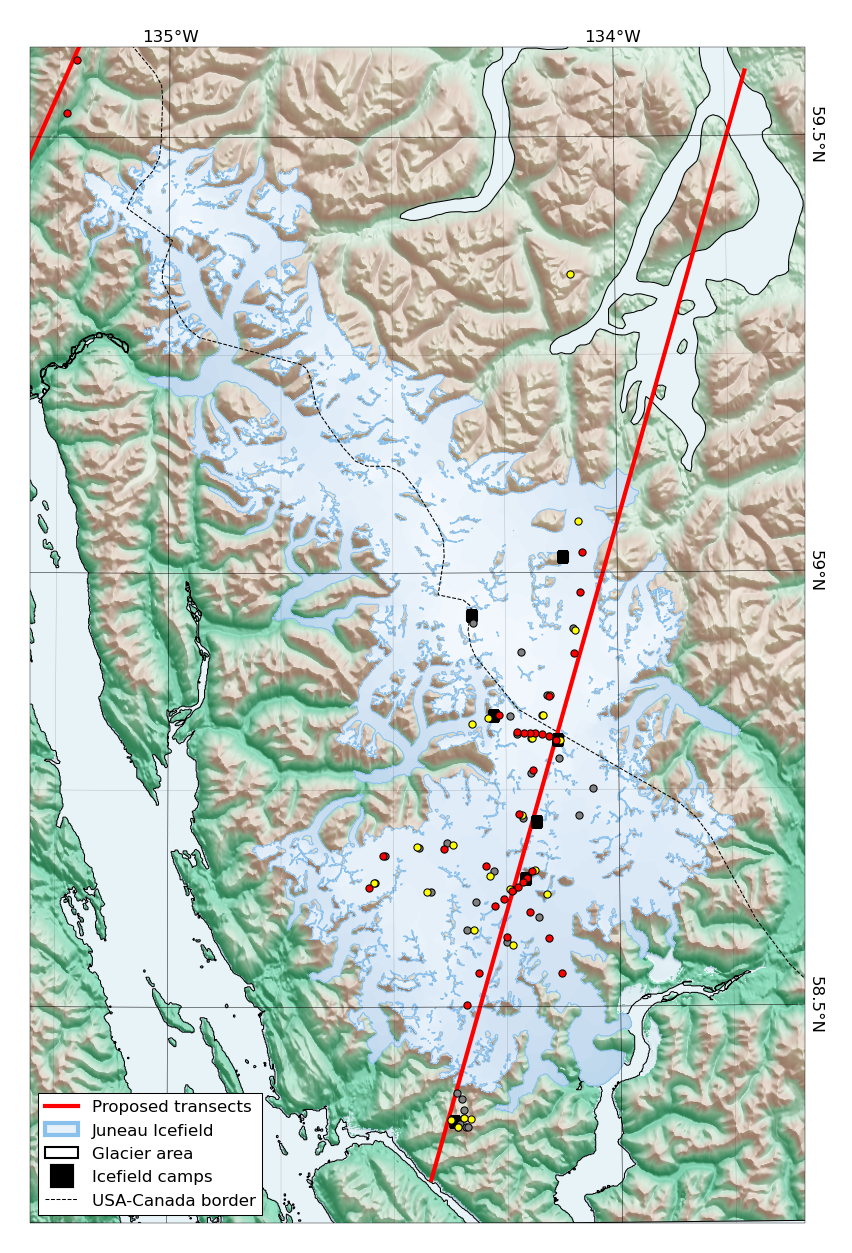

In [14]:

#%%

# todo: tagish lake? douglas island
# todo: clip the dem over water or coverthe contours

#res = '10m' 
res = '100m'  # for faster plotting
cLat = (latN + latS) / 2
cLon = (lonW + lonE) / 2
proj = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)

aspect_ratio = np.maximum(*dem.shape)/np.minimum(*dem.shape)
width = 3.25

fig = plt.figure(figsize=(width, width*aspect_ratio),dpi=300, layout='constrained', linewidth=0.25)
mapax = fig.add_subplot(111, projection=proj)
extent = [-135.3, lonE-0.1, latS, 59.6]
mapax.set_extent(extent, crs=ccrs.PlateCarree())

###################################################################################
# Plot hillshade, landscape features
###################################################################################

mapax.imshow(
    hillshade,
    origin='lower',
    extent=[dem.x.min(), dem.x.max(), dem.y.max(), dem.y.min()],
    transform=ccrs.PlateCarree()
)

ocean.plot(ax=mapax, fc=ocean_color, ec='black', lw=0.25, transform=ccrs.PlateCarree())
lakes.plot(ax=mapax, fc=lake_color, ec='black', lw=0.25, transform=ccrs.PlateCarree())



# rgi_other.plot(
#     ax=mapax,
#     legend=False,
#     transform=ccrs.PlateCarree(),
#     color='#FFF',
#     lw=0.1,
#     #alpha=0.9,
#     #ec='#A7DBF9',
#     #ec="#8ACBED",
#     ec='#000',
#     zorder=1.9,
# )

###################################################################################
# Plot JIF outline
###################################################################################

jif.plot(
    #column="rgi_id",
    ax=mapax,
    legend=False,
    #color='#D8F0FB',
    lw=0.25,
    ec="#8AC0EC",
    facecolor='none',
    transform=ccrs.PlateCarree(),
    zorder=1.9,
    marker=''
)

###################################################################################
# Plot JIF DEM, contours
###################################################################################

jif_bounds = tuple(np.array(jif_dem.rio.bounds())[[0, 2, 3, 1]])
dem_bounds = tuple(np.array(dem.rio.bounds())[[0, 2, 3, 1]])
maj_levels = np.arange(vmin, vmax, 250)
jif_cmap = mpl.colors.LinearSegmentedColormap.from_list("jif_cmap", plt.cm.Blues(np.linspace(0.3, 0, 256)))
clevels = np.arange(vmin, vmax-200, 100)
mapax.contourf(
    jif_dem,
    cmap=jif_cmap,
    zorder=1.8,
    extent=jif_bounds,
    levels=clevels,
    transform=ccrs.PlateCarree(),
    lw=0,
)
# cmaj_jif = mapax.contour(
#     jif_dem,
#     levels=maj_levels,
#     colors='#445E74',
#     linewidths=0.1,
#     extent=jif_bounds,
#     transform=ccrs.PlateCarree(),
#     zorder=1.9,
# )
# mapax.clabel(cmaj_jif, cmaj_jif.levels, inline=True, fontsize=1)
# # off-ice contours
# cmaj = mapax.contour(
#     dem_icefree,
#     levels=np.arange(vmin, vmax, 500),
#     colors='black',
#     linewidths=0.1,
#     linestyle=":",
#     extent=dem_bounds,
#     transform=ccrs.PlateCarree(),
#     zorder=1.9,
# )
# mapax.clabel(cmaj, cmaj.levels, inline=True, fontsize=1)


###################################################################################
# Plot build geography
###################################################################################

# Plot the highway and international border
# road = gpd.read_file(Path("/Users/drotto/src/jiflr/data/external/skagway-to-atlin.geojson"))
# road = road.iloc[[0]]['geometry'].explode().iloc[0]
# road = road.segmentize(1)
# y,x,_ = zip(*road.coords)
# mapax.plot(y, x, lw=0.75, ls="--", color='black', transform=ccrs.PlateCarree())
mapax.add_feature(cfeature.BORDERS.with_scale('10m'), edgecolor='black', lw=0.25, zorder=1.9, ls='--')


# Plot the cities
# mapax.scatter(coords.geometry.x, coords.geometry.y, s=8, lw=0.25, color='red', transform=ccrs.PlateCarree(), zorder=2)
# # Annotate the points
# for x, y, label in zip(coords.geometry.x, coords.geometry.y, coords.index):
#     mapax.text(x-0.025, y+0.025, label, fontsize=5.5, ha='right', fontweight='bold', transform=ccrs.PlateCarree())


###################################################################################
# Plot transects
###################################################################################

# plot the main transect
y,x = zip(*main_transect.coords)
mapax.plot(x, y, lw=1, c='red', marker='', transform=ccrs.PlateCarree(), zorder=2)
# plot the 2nd transect
y,x = zip(*control_transect.coords)
mapax.plot(x, y, lw=1, c='red', marker='', transform=ccrs.PlateCarree(), zorder=2)

###################################################################################
# plot wx locations
###################################################################################

# for y, x, label in zip(wx_pts.geometry.x, wx_pts.geometry.y, wx_pts.index):
#     mapax.plot(x, y, lw=0, markersize=3, markeredgewidth=0, 
#                c='black', marker='o', transform=ccrs.PlateCarree(), zorder=1.9)
    

###################################################################################
# plot contents of the geojason
###################################################################################

# # Plot shapes (lines)
# if shapes_gdf is not None:
#     for idx, shape in shapes_gdf.iterrows():
#         color = 'black'
#         width = 1
#         opacity = 1
        
#         # For LineString features
#         if shape.geometry.geom_type == 'LineString':
#             x, y = shape.geometry.xy
#             mapax.plot(
#                 x, y, 
#                 transform=ccrs.PlateCarree(),
#                 color=color,
#                 linewidth=width,
#                 alpha=opacity,
#                 zorder=2.2
#             )

# Plot camps with special styling (if desired)
if filtered_camps_markers is not None:
    mapax.scatter(
        filtered_camps_markers.geometry.x, filtered_camps_markers.geometry.y,
        transform=ccrs.PlateCarree(),
        color='black',
        s=5,
        marker='s',
        edgecolor='black',
        linewidth=0.5,
        zorder=2.6,
        label='Camps'
    )
# if label in ['Camp 17', 'Camp 10', 'Camp 18']:
#         mapax.text(x+0.01, y+0.02, label, fontsize=4.5, ha='left', fontweight='bold', transform=ccrs.PlateCarree())

# Plot 2024 stakes
if stakes_markers is not None:
    mapax.scatter(
        stakes_markers.geometry.x, stakes_markers.geometry.y,
        transform=ccrs.PlateCarree(),
        facecolor='yellow',
        s=3,
        marker='o',  # Square for stakes
        edgecolor='k',
        linewidth=0.25,
        zorder=3,
        label='Stake Locations'
    )

# Plot 2025 stakes
if stakes_markers is not None:
    mapax.scatter(
        stakes_2025.geometry.x, stakes_2025.geometry.y,
        transform=ccrs.PlateCarree(),
        facecolor='red',
        s=3,
        marker='o',  # Square for stakes
        edgecolor='k',
        linewidth=0.25,
        zorder=3,
        label='Stake Locations'
    )

# Plot MB pits
if pits_markers is not None:
    mapax.scatter(
        pits_markers.geometry.x, pits_markers.geometry.y,
        transform=ccrs.PlateCarree(),
        facecolor='grey',
        s=3,
        marker='o',  
        edgecolor='black',
        linewidth=0.25,
        zorder=2.6,
        label='MB Pits'
    )


###################################################################################
# Gridlines
###################################################################################
gl_maj = mapax.gridlines(
    draw_labels=['top', 'right'], linewidth=0.1, color='black',
    alpha=1,
    linestyle='-',
    xlocs=mpl.ticker.MultipleLocator(1),
    ylocs=mpl.ticker.MultipleLocator(0.5),
    x_inline=False, y_inline=False,
    xlabel_style={'fontsize': '4', "rotation":0, "ha":'center'},
    ylabel_style={'fontsize': '4', "rotation":270, "ha":'center'},
    xpadding=2.5,
    ypadding=2.5,
    rotate_labels=90,
    
)
gl_min = mapax.gridlines(
    draw_labels=False,
    linewidth=0.1,
    color='black',
    alpha=0.25,
    linestyle='-',
    xlocs=mpl.ticker.MultipleLocator(0.25),
    ylocs=mpl.ticker.MultipleLocator(0.25),
)


###################################################################################
# custom legend
###################################################################################
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], color='red', lw=1, label='Proposed transect'),
    Patch(facecolor='#E7F1FA', edgecolor='#8AC0EC', label='Juneau Icefield'),
    Patch(facecolor='#fff', edgecolor='k', label='Glacier area', lw=0.5),
    #Line2D([0], [0], marker='^', color='black', label='Prior field sites', markerfacecolor='tab:blue', markersize=4, lw=0, markeredgewidth=0.25, fillstyle='right', markerfacecoloralt='tab:orange'),
    Line2D([0], [0], marker='s', color='k', label='Icefield camps', markerfacecolor='k', markersize=5, lw=0),
    Line2D([0], [0], color='black', lw=0.25, ls='--', label='USA-Canada border'),
]
leg = mapax.legend(handles=legend_elements, loc='lower left', fontsize=4, framealpha=1, fancybox=False, edgecolor='black')
leg.get_frame().set_linewidth(0.25)


###################################################################################
# Show and save
###################################################################################

plt.savefig(f'jif-map_zoom-jif_{datetime.now().strftime("%Y%m%d-%H%M%S")}.png', bbox_inches='tight')
#plt.savefig(f'jif-map_{datetime.now().strftime("%Y%m%d-%H%M%S")}.svg', bbox_inches='tight')